In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Unemployment in India.csv")

In [3]:
df.columns = df.columns.str.strip()

In [4]:
df.shape

(768, 7)

In [5]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [7]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [8]:
df[df.isnull().any(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df = df.dropna()

In [10]:
df.shape

(740, 7)

In [11]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [12]:
df['Date'].head()

0     31-05-2019
1     30-06-2019
2     31-07-2019
3     31-08-2019
4     30-09-2019
Name: Date, dtype: str

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\minic\AppData\Local\Temp\ipykernel_16768\2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 46.2 KB


In [15]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [17]:
df['Year'] = df['Date'].dt.year

In [18]:
df[['Date','Year']].head()

,Date,Year
0,2019-05-31,2019
1,2019-06-30,2019
2,2019-07-31,2019
3,2019-08-31,2019
4,2019-09-30,2019


In [23]:
df['Month'] = df['Date'].dt.month

In [24]:
df[['Date','Month','Year']].head()

,Date,Month,Year
0,2019-05-31,5,2019
1,2019-06-30,6,2019
2,2019-07-31,7,2019
3,2019-08-31,8,2019
4,2019-09-30,9,2019


In [25]:
df['Year'].value_counts()

Year
2019    430
2020    310
Name: count, dtype: int64

In [26]:
df.groupby('Year')['Estimated Unemployment Rate (%)'].mean()

Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64

In [ ]:
# The average unemployment rate increased from approximately 9.4% in 2019 to 15.1% in 2020, 
# indicating a significant rise in unemployment during the Covid-19 period.

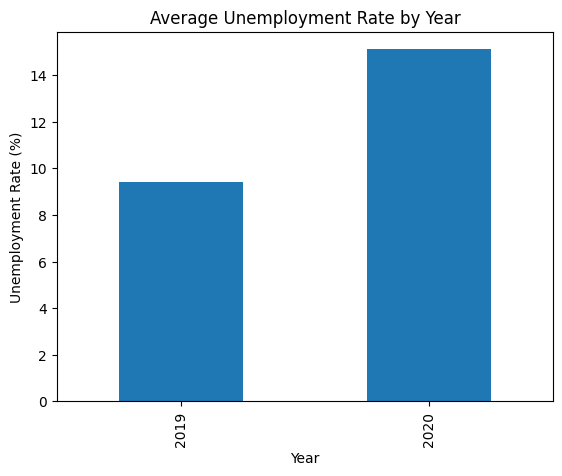

In [30]:
import matplotlib.pyplot as plt

df.groupby('Year')['Estimated Unemployment Rate (%)'].mean().plot(kind='bar')

plt.title('Average Unemployment Rate by Year')
plt.ylabel('Unemployment Rate (%)')
plt.show()

In [ ]:
# The average unemployment rate increased significantly from 9.4% in 2019 to 15.1% in 2020. 
# This suggests that the Covid-19 period had a strong negative impact on employment

In [31]:
df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

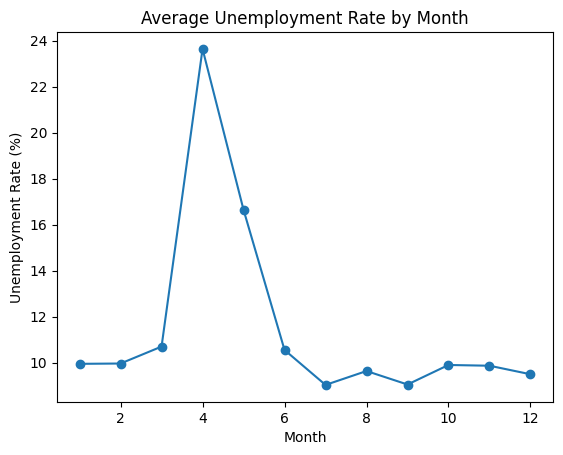

In [38]:
df.groupby('Month')['Estimated Unemployment Rate (%)'].mean().plot(
    kind='line',
    marker='o'
)

plt.title('Average Unemployment Rate by Month')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.show()

In [39]:
# The unemployment rate remained around 10% during the first three months. However, a sharp increase to approximately 24% was observed in April 2020. 
# This coincides with the nationwide Covid-19 lockdown period, suggesting a strong negative impact on employment opportunities.

In [40]:
df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

In [ ]:
# Tripura and Haryana recorded the highest average unemployment rates, 
# while Meghalaya and Odisha reported comparatively lower unemployment levels.

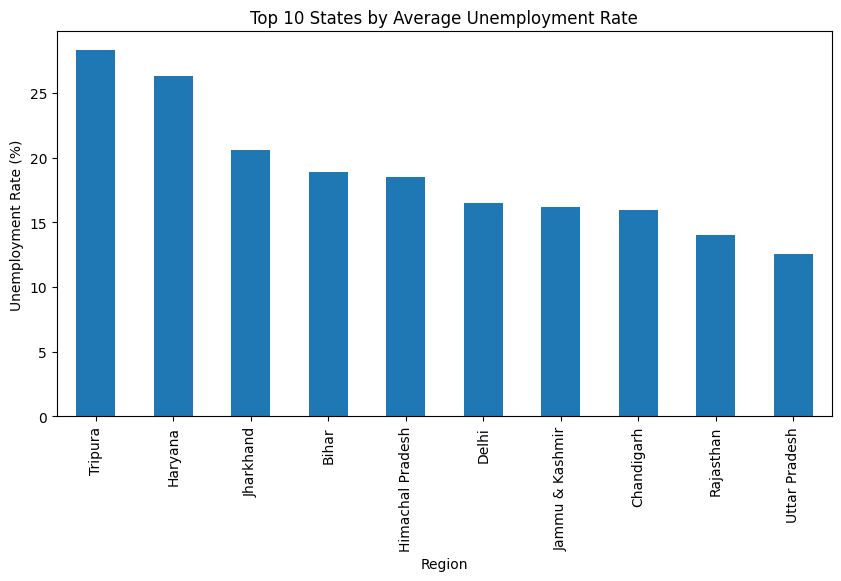

In [41]:
df.groupby('Region')['Estimated Unemployment Rate (%)'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10) \
  .plot(kind='bar', figsize=(10,5))

plt.title('Top 10 States by Average Unemployment Rate')
plt.ylabel('Unemployment Rate (%)')
plt.show()

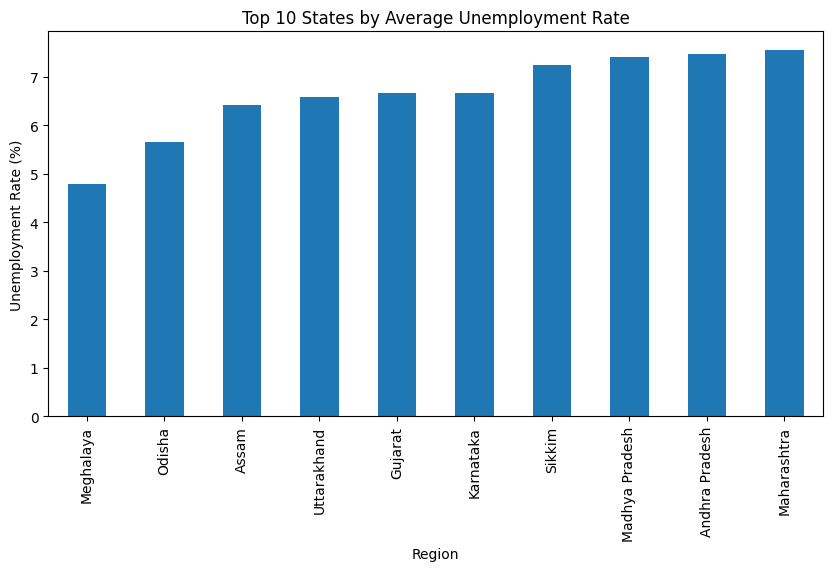

In [43]:
df.groupby('Region')['Estimated Unemployment Rate (%)'] \
  .mean() \
  .sort_values(ascending=True) \
  .head(10) \
  .plot(kind='bar', figsize=(10,5))

plt.title('Top 10 States by Average Unemployment Rate')
plt.ylabel('Unemployment Rate (%)')
plt.show()

In [44]:
df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64

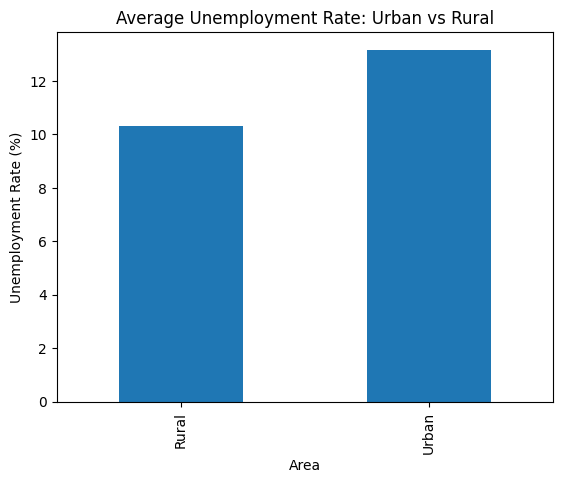

In [45]:
df.groupby('Area')['Estimated Unemployment Rate (%)'].mean().plot(
    kind='bar'
)

plt.title('Average Unemployment Rate: Urban vs Rural')
plt.ylabel('Unemployment Rate (%)')
plt.show()

In [ ]:
# Urban areas recorded a higher average unemployment rate (13.17%) than rural areas (10.32%), 
# suggesting that urban employment was more severely impacted during the study period.